# Results for the Conference Paper

**Receiver-Domain Behavioral Probing for Backdoor-Resilient Federated GPS Spoofing Detection in UAV Networks**
Group 1: Will Jedrzejczak, Cole Walther, Dilpreet Gill

This notebook reproduces exactly the results reported in the paper:
**Table I** and **Figures 2, 3 and 4**. Every value is read from an
exported CSV, so the notebook, the tables and the figures cannot disagree.

Studies the paper only summarises in prose (hyperparameter sweep, cost scaling,
detector ceiling, root-set stress) live in the Week 12 artifact. They are not
repeated here, for the same reason they are not tabulated in the paper: they do
not carry the main argument.

## Setup

`RUN_EXPERIMENTS = False` loads exported results and runs in seconds.
`True` re-executes the experiments through the shared harness (several hours on CPU).
Both paths run the same code, so they agree by construction.

In [1]:
RUN_EXPERIMENTS = False

import subprocess, sys
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

HERE = Path.cwd(); RES = HERE / 'results'; FIG = HERE / 'figures'
pd.set_option('display.width', 200)

def val(s):
    s = str(s).strip()
    if s in ('---', '', 'nan'): return None
    return s.split('+/-')[0].strip()

def run(script):
    if not RUN_EXPERIMENTS:
        print(f'[skipped] {script}  (set RUN_EXPERIMENTS = True to execute)'); return
    print(f'[running] {script}')
    r = subprocess.run([sys.executable, '-u', script], cwd=HERE)
    print(f'[{"ok" if r.returncode == 0 else "FAILED"}] {script}')

print('mode:', 'RECOMPUTE' if RUN_EXPERIMENTS else 'load exported results')
print(f'{len(list(RES.glob("*.csv")))} CSVs, {len(list(FIG.glob("*.png")))} figures')

mode: load exported results
17 CSVs, 3 figures


In [2]:
import fl_common as F
from fl_runner import ALL_RULES
print('probe features :', F.PROBE_FEATS, f'({len(F.PROBE_FEATS)} of {len(F.FEATURES)})')
print('model params   :', F.n_params(F.BinaryDNN(F.D)))
print('pool/root/test :', len(F.X_pool_sc), len(F.X_root_sc), len(F.X_test_sc))
print('rules          :', ALL_RULES)
print('seeds          :', F.SEEDS, '| data seed', F.DATA_SEED)

probe features : ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0'] (8 of 10)
model params   : 3329
pool/root/test : 114000 6000 30000
rules          : ['fedavg', 'accweight', 'median', 'trimmed', 'krum', 'multikrum', 'fltrust', 'trust', 'full']
seeds          : [42, 7, 123] | data seed 42


---
## Table I: comparison on an identical pipeline

Every rule sees the same split, attack, seeds and metrics. All ten rows of the
paper's Table I are reproduced below, in the paper's order and with the paper's
columns.

In [3]:
run('exp_baselines.py')

[skipped] exp_baselines.py  (set RUN_EXPERIMENTS = True to execute)


In [4]:
b = pd.read_csv(RES / 'baseline_comparison.csv')
rows = ['Honest FedAvg (no attack)', 'FedAvg', 'Accuracy-weighted FedAvg',
        'Coordinate-wise median', 'Trimmed mean', 'Krum', 'Multi-Krum', 'FLTrust',
        'Behavioral trust (ours)', 'Trust + median (ours, D2)']
t1 = b[b['Method'].isin(rows)].set_index('Method').loc[rows]
display(t1[['Clean Accuracy', 'Spoofing Recall', 'BSR', 'Backdoor Lift',
            'Attacker Detect', 'Honest False-Flag', 'Server ms/round']])
display(Markdown(
  '**What this table establishes.** The attack is effective (+0.2415) and quiet; '
  'accuracy inflation makes it worse (+0.3036), so weighting by an unverified '
  'self-report is worse than not weighting at all; median alone leaves +0.0646; '
  'FLTrust leaves +0.0787; **Multi-Krum is genuinely competitive** (+0.0061) and '
  'the paper says so; the proposed method reaches -0.0265 and additionally '
  'attributes the attack per client at a 0.3% honest false-flag rate.'))

,Clean Accuracy,Spoofing Recall,BSR,Backdoor Lift,Attacker Detect,Honest False-Flag,Server ms/round
Method,,,,,,,
Honest FedAvg (no attack),0.7112 +/- 0.0019,0.5292 +/- 0.0115,0.6367 +/- 0.0141,+0.0000 +/- 0.0000,---,---,1.0 +/- 0.0
FedAvg,0.6932 +/- 0.0032,0.3641 +/- 0.0096,0.8782 +/- 0.0178,+0.2415 +/- 0.0048,---,---,1.0 +/- 0.0
Accuracy-weighted FedAvg,0.6897 +/- 0.0046,0.3524 +/- 0.0148,0.9402 +/- 0.0096,+0.3036 +/- 0.0124,0.0%,0.0%,1.3 +/- 0.0
Coordinate-wise median,0.7101 +/- 0.0035,0.5008 +/- 0.0133,0.7013 +/- 0.0072,+0.0646 +/- 0.0074,---,---,0.9 +/- 0.0
Trimmed mean,0.7061 +/- 0.0021,0.4808 +/- 0.0121,0.7154 +/- 0.0099,+0.0787 +/- 0.0065,---,---,1.4 +/- 0.0
Krum,0.7071 +/- 0.0019,0.5168 +/- 0.0116,0.6698 +/- 0.0165,+0.0331 +/- 0.0035,100.0%,---,1.4 +/- 0.1
Multi-Krum,0.7108 +/- 0.0021,0.5282 +/- 0.0165,0.6428 +/- 0.0102,+0.0061 +/- 0.0041,100.0%,---,1.4 +/- 0.0
FLTrust,0.6962 +/- 0.0009,0.4687 +/- 0.0178,0.7154 +/- 0.0141,+0.0787 +/- 0.0176,84.7%,0.0%,204.4 +/- 0.3
Behavioral trust (ours),0.7112 +/- 0.0017,0.5307 +/- 0.0140,0.6406 +/- 0.0102,+0.0039 +/- 0.0047,100.0%,0.3%,38.0 +/- 0.3


**What this table establishes.** The attack is effective (+0.2415) and quiet; accuracy inflation makes it worse (+0.3036), so weighting by an unverified self-report is worse than not weighting at all; median alone leaves +0.0646; FLTrust leaves +0.0787; **Multi-Krum is genuinely competitive** (+0.0061) and the paper says so; the proposed method reaches -0.0265 and additionally attributes the attack per client at a 0.3% honest false-flag rate.

---
## Fig. 2: unknown number of compromised clients

Table I gives the Byzantine-robust rules the true value of $f$. A deployment does
not have it. Here the true attacker count varies while those rules stay at $f=2$.

In [5]:
run('exp_attacker_count.py')

[skipped] exp_attacker_count.py  (set RUN_EXPERIMENTS = True to execute)


True attackers,1,2,3,4
Method,,,,
Coordinate-wise median,+0.0275,+0.0646,+0.0977,+0.1453
FLTrust,+0.0626,+0.0787,+0.0919,+0.1059
Krum (f=2),+0.0215,+0.0331,+0.0177,+0.0172
Multi-Krum (f=2),+0.0005,+0.0061,+0.1609,+0.2837
Trimmed mean (f=2),+0.0380,+0.0787,+0.2114,+0.2992
Trust + median (ours),-0.0142,-0.0265,-0.0172,+0.0114


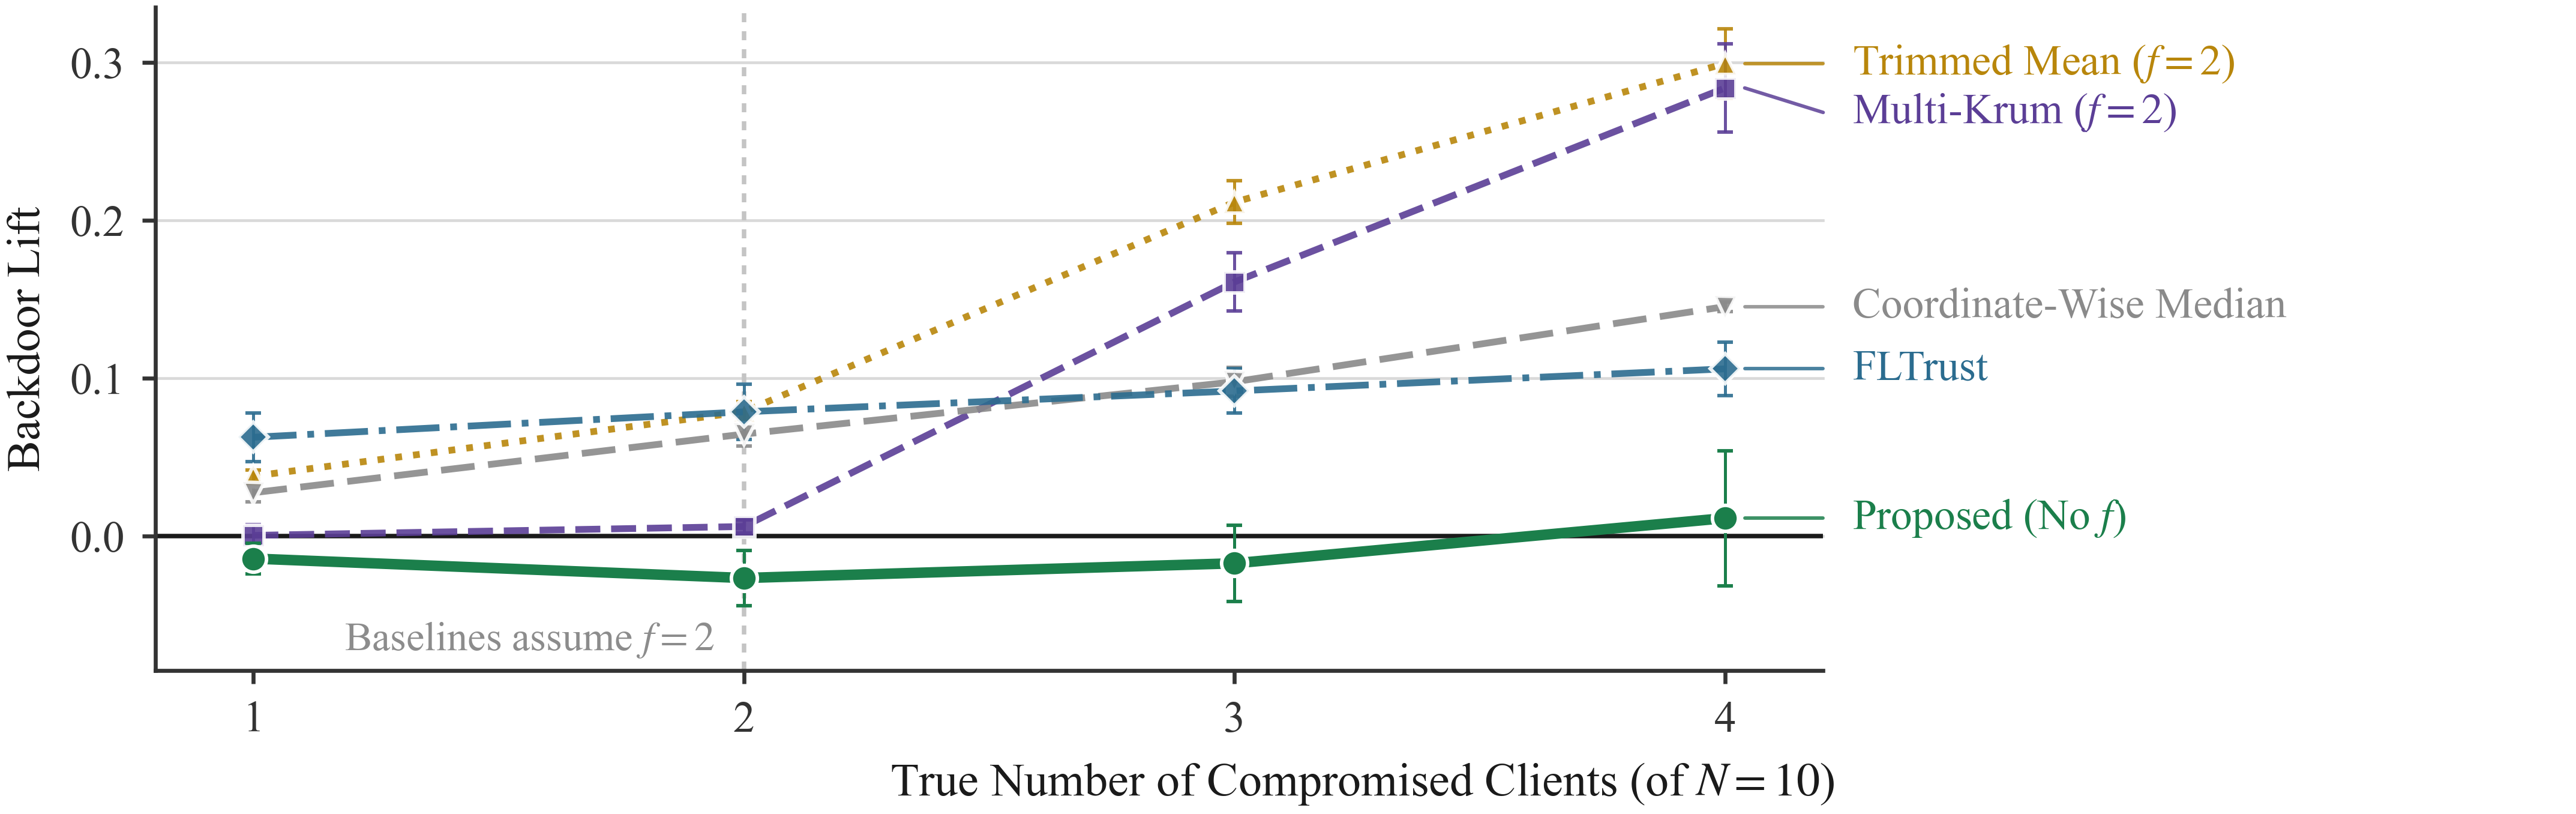

**The point is not that Multi-Krum is weak.** It is excellent when told the right f (+0.0005 at one attacker), and degrades to +0.2837 at four. The proposed method has no such parameter.

In [6]:
a = pd.read_csv(RES / 'attacker_count.csv')
piv = a.pivot_table(index='Method', columns='True attackers',
                    values='Backdoor Lift', aggfunc='first')
display(piv.map(val))
display(Image(filename=str(FIG / 'fig2_fcount.png'), width=760))
display(Markdown(
  '**The point is not that Multi-Krum is weak.** It is excellent when told the '
  'right f (+0.0005 at one attacker), and degrades to +0.2837 at four. The '
  'proposed method has no such parameter.'))

---
## Fig. 3: client heterogeneity, and where the mechanism fails

Clients hold equal row counts but unequal benign/spoofed ratios. This is the
paper's honest boundary, and it is reported rather than omitted.

In [7]:
run('exp_noniid.py')

[skipped] exp_noniid.py  (set RUN_EXPERIMENTS = True to execute)


'                Condition                  Method      Backdoor Lift Attacker Detect    Attacker Trust      Honest Trust\n                      IID                  FedAvg +0.2415 +/- 0.0048             ---               ---               ---\n                      IID  Coordinate-wise median +0.0646 +/- 0.0074             ---               ---               ---\n                      IID Behavioral trust (ours) +0.0039 +/- 0.0047          100.0% 0.0001 +/- 0.0001 0.1250 +/- 0.0000\n                      IID   Trust + median (ours) -0.0265 +/- 0.0174          100.0% 0.0001 +/- 0.0001 0.1250 +/- 0.0000\n   Ratio skew a=10 (mild)                  FedAvg +0.2583 +/- 0.0337             ---               ---               ---\n   Ratio skew a=10 (mild)  Coordinate-wise median +0.0710 +/- 0.0209             ---               ---               ---\n   Ratio skew a=10 (mild) Behavioral trust (ours) +0.2374 +/- 0.0404            0.0% 0.0950 +/- 0.0023 0.1013 +/- 0.0006\n   Ratio skew a=10 (mil

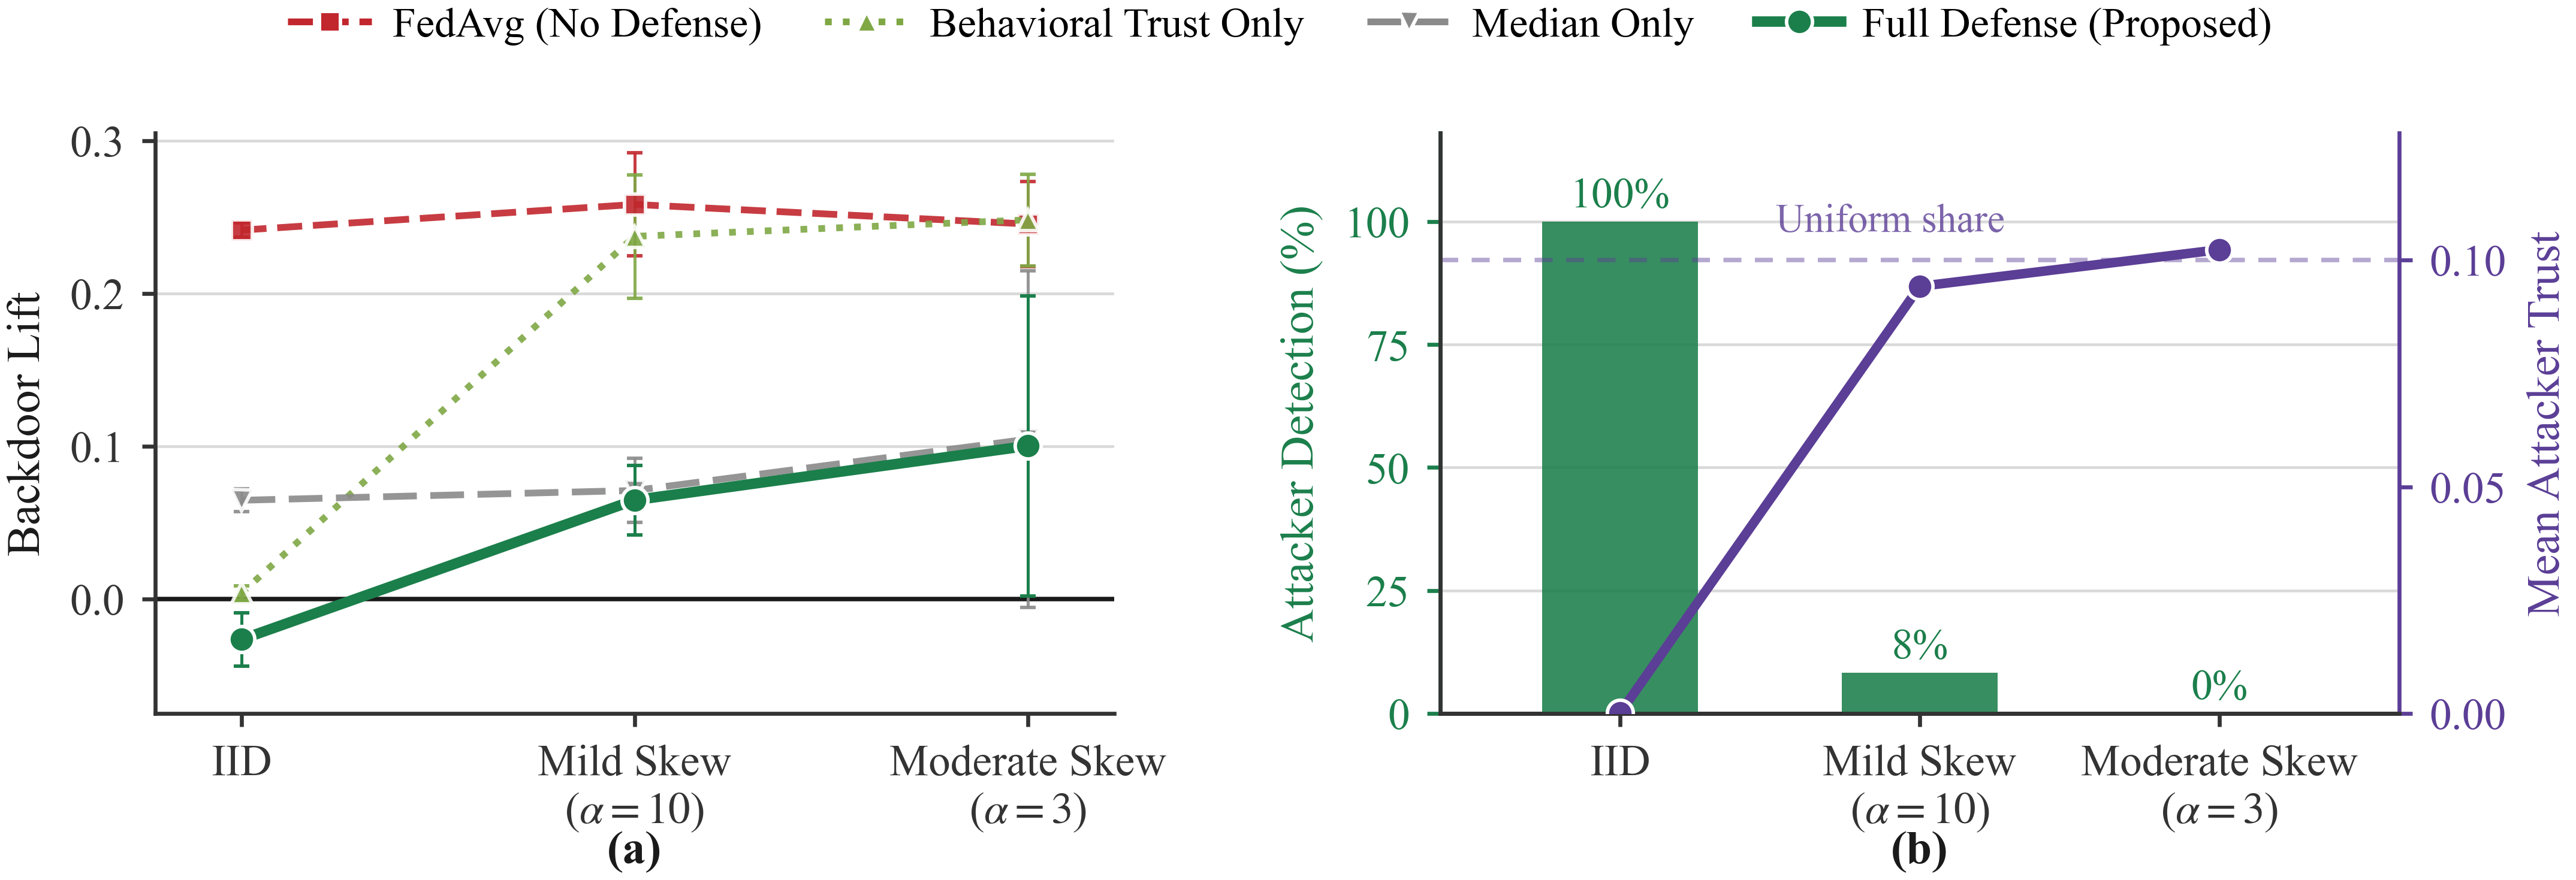

In [8]:
n = pd.read_csv(RES / 'noniid_dirichlet.csv')
keep = ['IID', 'Ratio skew a=10 (mild)', 'Ratio skew a=3 (moderate)']
m = ['FedAvg', 'Coordinate-wise median', 'Behavioral trust (ours)', 'Trust + median (ours)']
sub = n[n['Condition'].isin(keep) & n['Method'].isin(m)]
display(sub[['Condition', 'Method', 'Backdoor Lift', 'Attacker Detect',
             'Attacker Trust', 'Honest Trust']].to_string(index=False))
display(Image(filename=str(FIG / 'fig3_noniid.png'), width=760))

In [9]:
display(Markdown(
  '**Diagnosis.** Suspicion is measured in cohort-MAD units. Under skew honest '
  'clients legitimately disagree, the MAD inflates, and the attacker no longer '
  'clears the dead-zone. Lowering tau confirms this but does not fix it:'))
display(pd.read_csv(RES / 'noniid_tau_diagnosis.csv'))

**Diagnosis.** Suspicion is measured in cohort-MAD units. Under skew honest clients legitimately disagree, the MAD inflates, and the attacker no longer clears the dead-zone. Lowering tau confirms this but does not fix it:

,Condition,Dead-zone tau,Backdoor Lift,Attacker Trust,Attacker Detect,Honest False-Flag,Spoofing Recall
0,IID,0.5,-0.0122 +/- 0.0114,0.0000 +/- 0.0000,100.0%,6.3%,0.5420 +/- 0.0112
1,IID,1.0,-0.0212 +/- 0.0294,0.0000 +/- 0.0000,100.0%,4.9%,0.5534 +/- 0.0273
2,IID,2.0,-0.0265 +/- 0.0174,0.0001 +/- 0.0001,100.0%,0.3%,0.5560 +/- 0.0194
3,Ratio skew a=10,0.5,+0.0457 +/- 0.0425,0.0598 +/- 0.0049,38.9%,11.8%,0.4876 +/- 0.0365
4,Ratio skew a=10,1.0,+0.0470 +/- 0.0329,0.0811 +/- 0.0027,26.4%,6.9%,0.4737 +/- 0.0249
5,Ratio skew a=10,2.0,+0.0647 +/- 0.0228,0.0942 +/- 0.0044,8.3%,2.1%,0.4555 +/- 0.0150
6,Ratio skew a=3,0.5,+0.0851 +/- 0.1120,0.0886 +/- 0.0059,15.3%,7.6%,0.3797 +/- 0.0708
7,Ratio skew a=3,1.0,+0.0902 +/- 0.1024,0.0982 +/- 0.0041,1.4%,1.7%,0.3738 +/- 0.0650
8,Ratio skew a=3,2.0,+0.1002 +/- 0.0982,0.1023 +/- 0.0020,0.0%,0.0%,0.3618 +/- 0.0562


In [10]:
run('exp_noniid_diagnosis.py')

[skipped] exp_noniid_diagnosis.py  (set RUN_EXPERIMENTS = True to execute)


---
## Fig. 4: trigger generalization

One fixed defense configuration, never retuned between trigger settings.

,Trigger,Cohen's d,Attack lift,Defended lift,Honest FP rate
0,CN0,0.288,+0.2457 +/- 0.0023,-0.0253 +/- 0.0178,0.3%
1,TCD,0.302,+0.2384 +/- 0.0729,-0.0626 +/- 0.0512,0.7%
2,PD,0.152,+0.0909 +/- 0.0106,-0.0188 +/- 0.0150,0.3%
3,CN0+TCD,0.288 + 0.302,+0.1933 +/- 0.0664,-0.0282 +/- 0.0173,0.7%


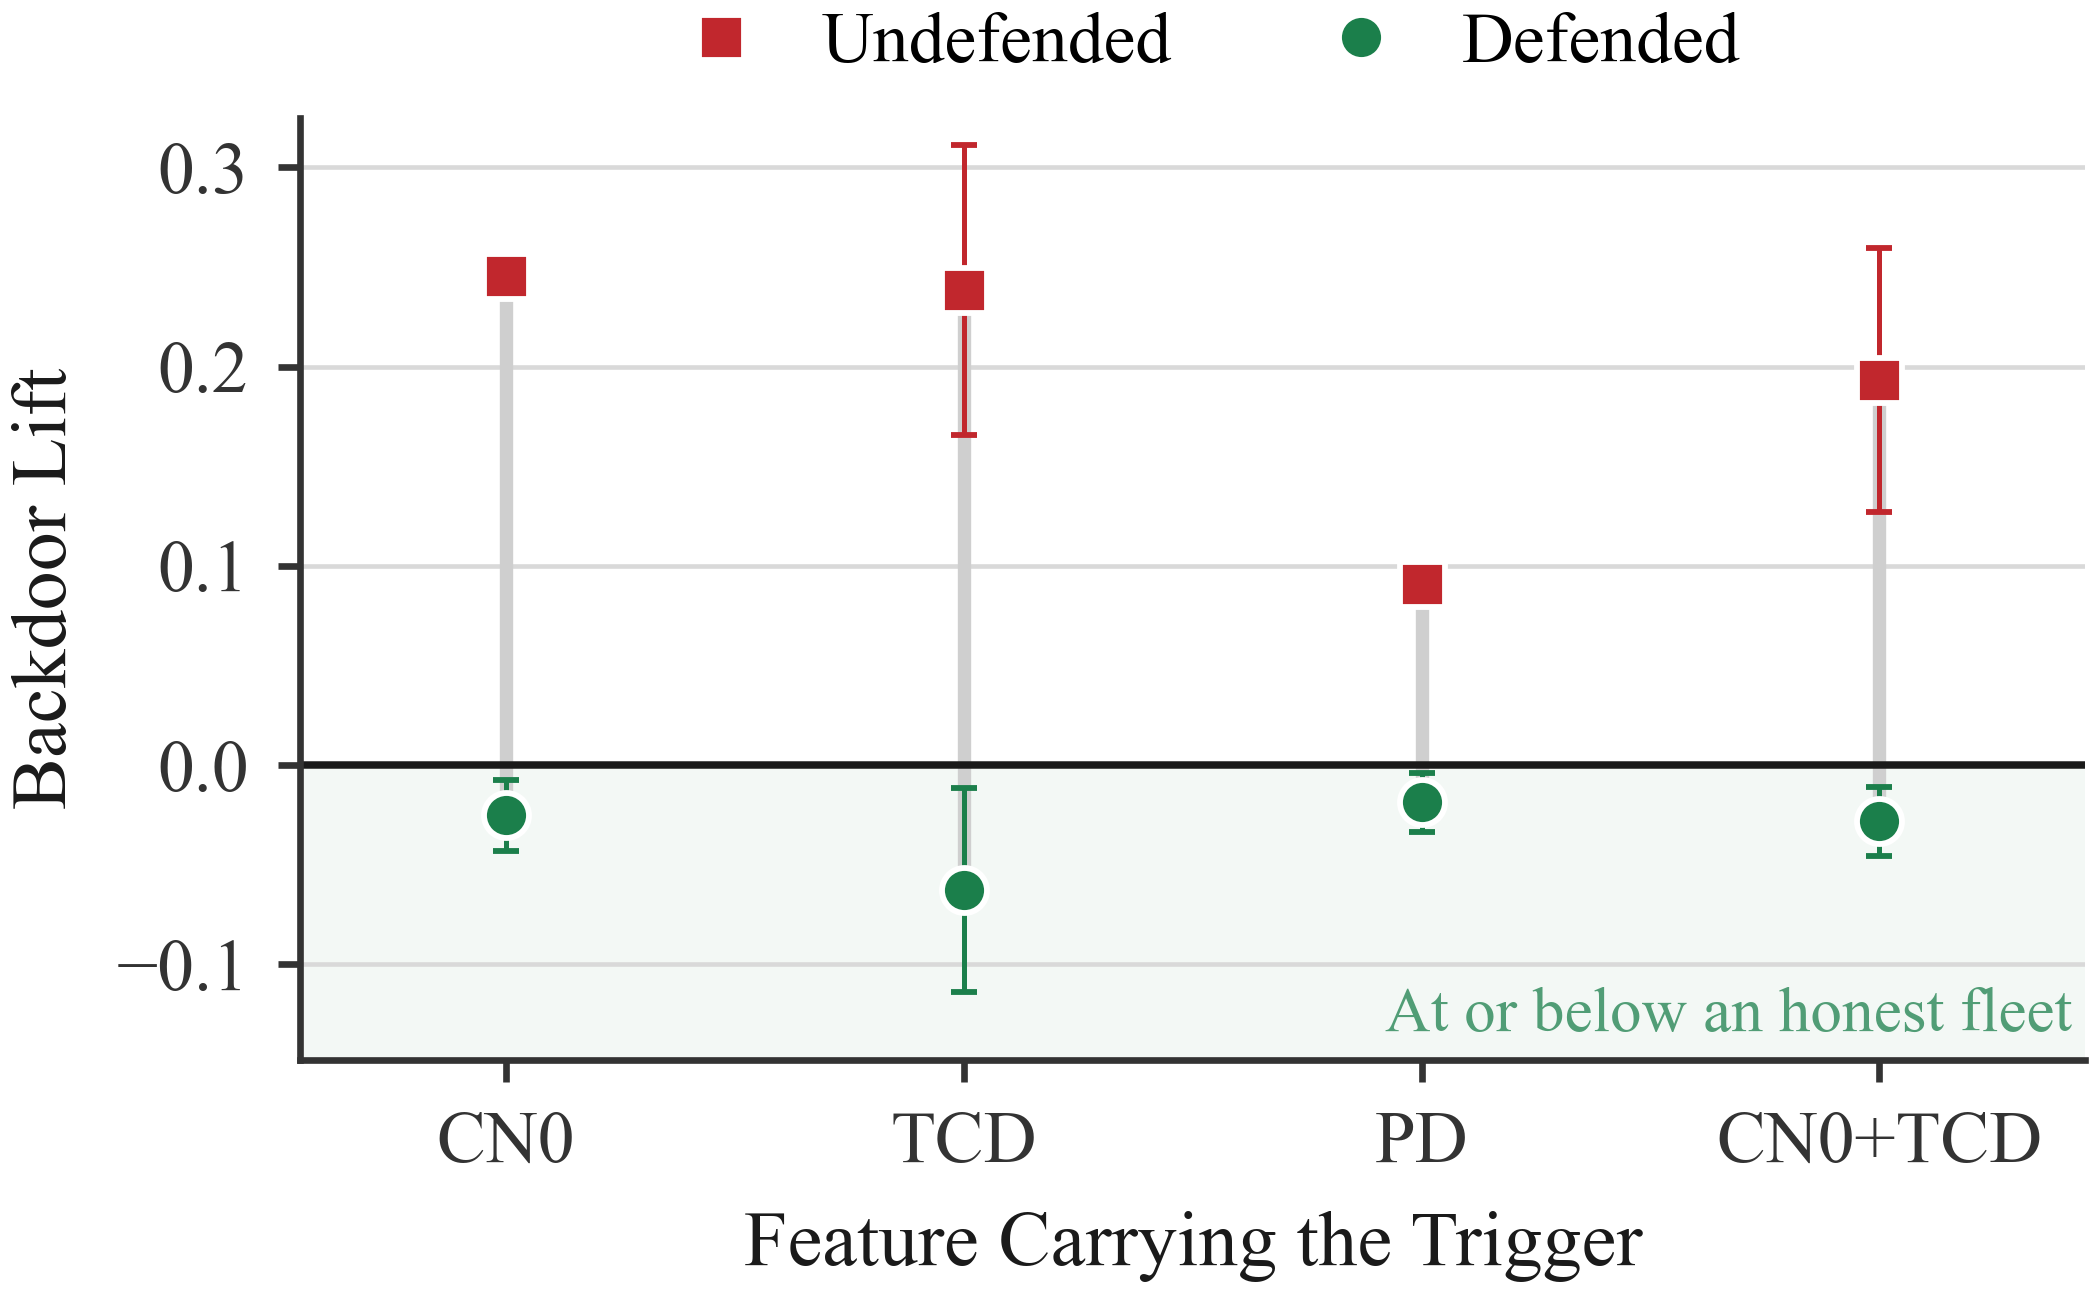

In [11]:
tg = pd.read_csv(RES / 'trigger_comparison.csv')
display(tg[tg['Trigger'].isin(['CN0', 'TCD', 'PD', 'CN0+TCD'])][
    ['Trigger', "Cohen's d", 'Attack lift', 'Defended lift', 'Honest FP rate']])
display(Image(filename=str(FIG / 'fig4_trigger.png'), width=430))

---
## Defense-aware adversary (reported in prose, no table)

`lambda` weights an evasion term that trains the compromised clients to answer
the probes like the honest cohort. The tension is the point: the trigger requires
calling a benign-high input authentic, and the evasion term trains the same model
to call it spoofed.

In [12]:
ad = pd.read_csv(RES / 'adaptive_attacker.csv')
display(ad)
display(Markdown(
  '**Read the undefended column, not the trust column.** Evasion does raise '
  'attacker trust from 0.0001 to 0.0834, close to the uniform share of 0.100. '
  'It buys nothing, because undefended lift has already collapsed to -0.1433 by '
  'then: an attacker that hides from the probes has destroyed its own backdoor.'))

,Evasion strength (lambda),Undefended lift,Defended lift (D2),Mean attacker trust
0,0.0,+0.2457 +/- 0.0023,-0.0253 +/- 0.0178,0.0001 +/- 0.0001
1,2.0,-0.1433 +/- 0.0439,-0.0534 +/- 0.0287,0.0834 +/- 0.0017
2,10.0,-0.4782 +/- 0.0464,-0.0829 +/- 0.0304,0.0740 +/- 0.0020


**Read the undefended column, not the trust column.** Evasion does raise attacker trust from 0.0001 to 0.0834, close to the uniform share of 0.100. It buys nothing, because undefended lift has already collapsed to -0.1433 by then: an attacker that hides from the probes has destroyed its own backdoor.

---
## Per-client attribution (reported in prose, no table)

12 rounds x 3 seeds = 36 client-rounds per client. A client counts as flagged in
a round when its trust falls below half the uniform share of 0.100. This is the
property the geometric rules cannot provide: they return a selection, not a name.

In [13]:
cf = pd.read_csv(RES / 'client_flagging_table.csv')
display(cf)
display(pd.read_csv(RES / 'false_positive_summary.csv'))

,Client,Role,Mean trust,Rounds flagged,Flag rate
0,C1,honest,0.120 +/- 0.026,1 / 36,2.8%
1,C2,honest,0.124 +/- 0.017,0 / 36,0.0%
2,C3,honest,0.125 +/- 0.019,0 / 36,0.0%
3,C4,honest,0.131 +/- 0.010,0 / 36,0.0%
4,C5,honest,0.131 +/- 0.011,0 / 36,0.0%
5,C6,honest,0.119 +/- 0.019,0 / 36,0.0%
6,C7,honest,0.119 +/- 0.027,0 / 36,0.0%
7,C8,honest,0.130 +/- 0.011,0 / 36,0.0%
8,C9,ATTACKER,0.000 +/- 0.000,36 / 36,100.0%
9,C10,ATTACKER,0.000 +/- 0.000,36 / 36,100.0%


,Metric,Count,Rate
0,Attacker client-rounds flagged (true positives),72 / 72,100.0%
1,Honest client-rounds flagged (false positives),1 / 288,0.3%
2,Attacker client-rounds fully excluded (trust=0),2 / 72,2.8%
3,Honest client-rounds fully excluded (trust=0),0 / 288,0.0%


---
## Regenerating the figures

Figures 2 to 4 are 600 dpi PNGs built from the CSVs above, so they cannot drift from
the tables. Figs. 2 and 3 are sized for the full text width, Fig. 4 for one column.
Figure 1 is the authors' own diagram and is not generated here.

In [14]:
r = subprocess.run([sys.executable, '-u', 'build_figures.py'],
                   cwd=HERE, capture_output=True, text=True)
print(r.stdout or r.stderr)

fig2_fcount.png      7.16 x 2.26 in  (scale 1.00)
fig3_noniid.png      7.16 x 2.45 in  (scale 1.00)
fig4_trigger.png     3.50 x 2.16 in  (scale 1.00)

wrote 3 figures to C:\Users\willi\uav-capstone\weeks\week14-conference-paper\figures



---
## Reproducing from scratch

```bash
python run_all.py --list      # stages and runtimes
python run_all.py baselines attackers noniid
python build_figures.py       # regenerate the four paper figures
```

The data split is fixed at seed 42 so the evaluation target never moves; federated
randomness varies over seeds 42, 7, 123. Runs are deterministic on a given machine,
verified by executing a benchmark twice for bit-identical output.